In [4]:
from src.data import pointcloud_processing, timeseries_processing, config, pc_statistics, utils
from src.data.config import TARGET_EXTENTS_VIF, TARGET_EXTENTS_VIF_SPLITS, ROOF_EXTENT, TARGET_DISTANCES
from src.visualization.timeseries import (
    plot_timeseries_separate_axes,
    target_stat_vs_precipitation,
    histograms_targets_attime,
    histogram_targets_interactive,
)
from src.data.utils import flatten_multiindex

import pandas as pd
import pickle

from matplotlib import pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

## Load Met Data from Bagfile

In [5]:
BAG_NAME = "molisens_met_2023_08_29-06_04_46_converted"
DATA_DIR = config.INTERIM_DATA_FOLDER / "ViF_Roof" / "data"

In [6]:
df_ws100 = timeseries_processing.load(
    DATA_DIR / BAG_NAME,
    "/sensing/aws/ws100_measurements",
    config.PATH_TO_LUFFT_MSGS,
    timestamp_source="header",
)
df_ws501 = timeseries_processing.load(
    DATA_DIR / BAG_NAME,
    "/sensing/aws/ws501_measurements",
    config.PATH_TO_LUFFT_MSGS,
    timestamp_source="header",
)

# Unify timestamp to concat the dataframes
# Set the ferquency of the index to 1s
df_ws100.index.asfreq = "S"
df_ws501.index.asfreq = "S"

# and round the index to the nearest second for easier analysis
df_ws100.index = df_ws100.index.round("S")
df_ws501.index = df_ws501.index.round("S")

df = pd.concat([df_ws100, df_ws501], axis=1)
df.loc[:, ("precipitation", "intensity_hour_shifted")] = df.precipitation.intensity_hour.shift(periods=-60, freq="S")

In [7]:
RESAMPLE_FREQ = "1min"
columns_and_aggregation = {
    ("precipitation", "intensity_hour_shifted"): "first",
    ("precipitation", "intensity_hour"): "first",
    ("precipitation", "differential"): "sum",
    ("precipitation", "total_precipitation_particles"): "sum",
    ("precipitation", "total_drops"): "sum",
    ("wind", "speed_avg"): "mean",
    ("temperature", "average"): "mean",
    ("humidity", "relative_avg"): "mean",
    ("pressure", "relative_avg"): "mean",
    ("radiation", "current"): "mean",
}

df_relevant = df.loc[:, columns_and_aggregation.keys()]

columns = flatten_multiindex(df_relevant)
df_relevant = df_relevant.resample(RESAMPLE_FREQ).agg({".".join(k): v for k, v in columns_and_aggregation.items()})

## Load PC data

In [8]:
# load from pickle
path = config.PROCESSED_DATA_FOLDER / "rain_minutes.pickle"
with open(path, "rb") as handle:
    ds_minutes = pickle.load(handle)

In [9]:
TIME_AGGREGATION = "mean"
SPACE_AGGREGATION = pc_statistics.mean_intensity

In [10]:
subtarget_statistics = pointcloud_processing.subset_and_aggregate_dataset(
    dataset=ds_minutes[TIME_AGGREGATION],
    splits=TARGET_EXTENTS_VIF_SPLITS,
    agg_func=SPACE_AGGREGATION,
    return_type="df",
)
subtarget_statistics.columns.names = ["target", "color"]

### Model Selection

In [11]:
X = df_relevant.precipitation.intensity_hour_shifted.values.reshape(-1, 1)
X[-1] = 0
y = subtarget_statistics["Target-03"]["white"].values

# Initialize and train the model
model = LinearRegression()
model.fit(X, y)

AttributeError: 'DataFrame' object has no attribute 'precipitation'

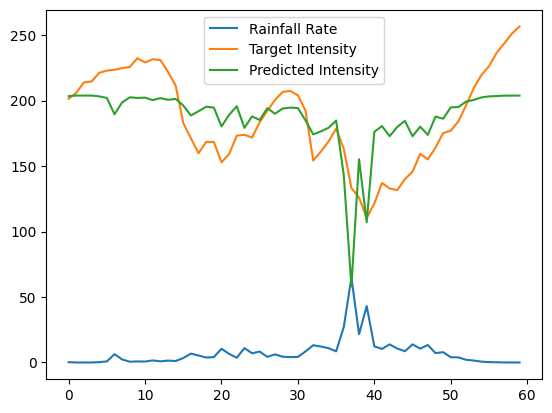

In [ ]:
# Make predictions
plt.plot(X, label="Rainfall Rate")
plt.plot(y, label="Target Intensity")
plt.plot([model.predict([x]) for x in X], label="Predicted Intensity")
plt.legend()

RMSE: 15882.639516523303
R-squared: 0.5048252488024807


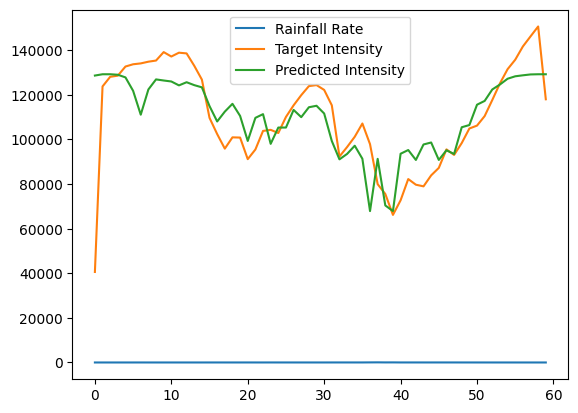

In [ ]:
# Define the degree of the polynomial
degree = 2

# Create polynomial features
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)


# Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.1, random_state=42)
X_train = X_test = X_poly
y_train = y_test = y

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")


# Make predictions
plt.plot(X, label="Rainfall Rate")
plt.plot(y, label="Target Intensity")
plt.plot(model.predict(X_train), label="Predicted Intensity")
plt.legend()

In [ ]:
regression_data = []
for target, color in subtarget_statistics.columns:
    if target == "Target-04" and color == "black":
        continue
    df = pd.DataFrame(
        {
            "rainfall_rate": df_relevant.precipitation.intensity_hour_shifted,
            "target_intensity": subtarget_statistics[target][color],
            "target": f"{target}_{color}",
            "distance": TARGET_DISTANCES[target],
        }
    )
    # Deal with nan in the last value for the rainfall rate
    df.loc[df.index[-1], "rainfall_rate"] = 0
    regression_data.append(df)

regression_data = pd.concat(regression_data)
regression_data

,rainfall_rate,target_intensity,target,distance
2023-08-29 04:05:00,0.21,201.239310,Target-01_white,6.38
2023-08-29 04:06:00,0.00,207.773993,Target-01_white,6.38
2023-08-29 04:07:00,0.00,212.167033,Target-01_white,6.38
2023-08-29 04:08:00,0.00,206.672033,Target-01_white,6.38
2023-08-29 04:09:00,0.26,207.867710,Target-01_white,6.38
...,...,...,...,...
2023-08-29 05:00:00,0.28,74.052624,Target-05_black,45.70
2023-08-29 05:01:00,0.16,77.668624,Target-05_black,45.70
2023-08-29 05:02:00,0.03,77.806058,Target-05_black,45.70
2023-08-29 05:03:00,0.00,85.420077,Target-05_black,45.70


In [ ]:
regression_data[y.isna()]

AttributeError: 'numpy.ndarray' object has no attribute 'isna'

In [ ]:
regression_data

,rainfall_rate,target_intensity,target,distance
2023-08-29 04:05:00,0.160169,40650.339844,Target-01_white,6.38
2023-08-29 04:06:00,0.000000,124664.398438,Target-01_white,6.38
2023-08-29 04:07:00,0.000000,127300.218750,Target-01_white,6.38
2023-08-29 04:08:00,0.060667,124003.218750,Target-01_white,6.38
2023-08-29 04:09:00,0.388333,124512.757812,Target-01_white,6.38
...,...,...,...,...
2023-08-29 05:00:00,0.252000,44400.000000,Target-05_black,45.70
2023-08-29 05:01:00,0.129667,46514.000000,Target-05_black,45.70
2023-08-29 05:02:00,0.023000,46600.500000,Target-05_black,45.70
2023-08-29 05:03:00,0.000000,51149.285156,Target-05_black,45.70


In [ ]:
X_train

array([[1.00000000e+00, 1.60169487e-01, 2.56542644e-02],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 6.06666644e-02, 3.68044417e-03],
       [1.00000000e+00, 3.88333327e-01, 1.50802773e-01],
       [1.00000000e+00, 2.10033337e+00, 4.41140027e+00],
       [1.00000000e+00, 5.40433343e+00, 2.92068198e+01],
       [1.00000000e+00, 1.92399994e+00, 3.70177575e+00],
       [1.00000000e+00, 6.38999983e-01, 4.08320978e-01],
       [1.00000000e+00, 7.76666673e-01, 6.03211121e-01],
       [1.00000000e+00, 9.00666644e-01, 8.11200404e-01],
       [1.00000000e+00, 1.39666663e+00, 1.95067766e+00],
       [1.00000000e+00, 9.95333358e-01, 9.90688493e-01],
       [1.00000000e+00, 1.36533338e+00, 1.86413523e+00],
       [1.00000000e+00, 1.64966669e+00, 2.72140020e+00],
       [1.00000000e+00, 4.17400008e+00, 1.74222767e+01],
       [1.00000000e+00, 6.41633337e+00, 4.11693340e+01],
       [1.00000000e+00, 4.96066

In [ ]:
# Feature Engineering
# regression_data['rainfall_rate_squared'] = df['rainfall_rate']**2
# df['range_squared'] = df['range']**2
# df['interaction'] = df['rainfall_rate'] * df['range']

# Define features and target
X = regression_data[
    ["rainfall_rate", "distance"]  ###### reflectiviy!!!!!
]  # , 'range', 'reflectivity', 'rainfall_rate_squared', 'range_squared', 'interaction']]
y = regression_data["target_intensity"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# List of models to evaluate
models = [
    ("Linear Regression", LinearRegression()),
    ("Polynomial Regression (Degree 3)", make_pipeline(PolynomialFeatures(degree=3), LinearRegression())),
    ("Random Forest Regression", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("Support Vector Regression", make_pipeline(StandardScaler(), SVR(kernel="rbf"))),
]

# Loop over models and evaluate
results = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append((name, rmse, r2))

    print(f"{name} - RMSE: {rmse}, R-squared: {r2}")

    # Plot the results
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=np.arange(len(regression_data)), y=regression_data["rainfall_rate"], mode="lines", name="Rainfall Rate"
        )
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(len(regression_data)),
            y=y,
            mode="lines",
            name="Target Intensity",
            text=regression_data["target"],
        )
    )
    fig.add_trace(
        go.Scatter(x=np.arange(len(regression_data)), y=model.predict(X), mode="lines", name="Predicted Intensity")
    )
    fig.update_layout(title=name)
    fig.show()


# Summarize results
for name, rmse, r2 in results:
    print(f"{name} - RMSE: {rmse:.4f}, R-squared: {r2:.4f}")

Linear Regression - RMSE: 67735.36117151697, R-squared: 0.12551866774180853


Polynomial Regression (Degree 3) - RMSE: 58724.35875928862, R-squared: 0.3427112370259945


Random Forest Regression - RMSE: 77005.53046362054, R-squared: -0.13022126710751292


Gradient Boosting Regression - RMSE: 61403.8000732249, R-squared: 0.28136206420095233


Support Vector Regression - RMSE: 78126.88853540816, R-squared: -0.16337760213785857


Linear Regression - RMSE: 67735.3612, R-squared: 0.1255
Polynomial Regression (Degree 3) - RMSE: 58724.3588, R-squared: 0.3427
Random Forest Regression - RMSE: 77005.5305, R-squared: -0.1302
Gradient Boosting Regression - RMSE: 61403.8001, R-squared: 0.2814
Support Vector Regression - RMSE: 78126.8885, R-squared: -0.1634
